In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"D:\Projects\Data\Supply_Chain_dataset.csv")

df['shipping_date_(DateOrders)'] = pd.to_datetime(df['shipping_date_(DateOrders)'])
df['order_date_(DateOrders)'] = pd.to_datetime(df['order_date_(DateOrders)'])
df = df.drop(columns="Order_Zipcode")
df = df.drop(columns="Product_Description")
df= df.drop(columns=['Product_Status'])
df = df.dropna()

C:\Users\minam\AppData\Local\Temp\ipykernel_49880\2195236869.py:13: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df= df.round(0)


In [2]:
df.info()

<class 'pandas.DataFrame'>
Index: 180508 entries, 0 to 180518
Data columns (total 50 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180508 non-null  str           
 1   Days_for_shipping_(real)       180508 non-null  int64         
 2   Days_for_shipment_(scheduled)  180508 non-null  int64         
 3   Benefit_per_order              180508 non-null  float64       
 4   Sales_per_customer             180508 non-null  float64       
 5   Delivery_Status                180508 non-null  str           
 6   Late_delivery_risk             180508 non-null  int64         
 7   Category_Id                    180508 non-null  int64         
 8   Category_Name                  180508 non-null  str           
 9   Customer_City                  180508 non-null  str           
 10  Customer_Country               180508 non-null  str           
 11  Customer_Email  

In [3]:
df.head()

,Type,Days_for_shipping_(real),Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_Region,Order_State,Order_Status,Product_Card_Id,Product_Category_Id,Product_Image,Product_Name,Product_Price,shipping_date_(DateOrders),Shipping_Mode
0,DEBIT,3,4,91.0,315.0,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,328.0,2018-02-03,Standard Class
1,TRANSFER,5,4,-249.0,311.0,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastan,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,328.0,2018-01-18,Standard Class
2,CASH,4,4,-248.0,310.0,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastan,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,328.0,2018-01-17,Standard Class
3,DEBIT,3,4,23.0,305.0,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,328.0,2018-01-16,Standard Class
4,PAYMENT,2,4,134.0,298.0,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,328.0,2018-01-15,Standard Class


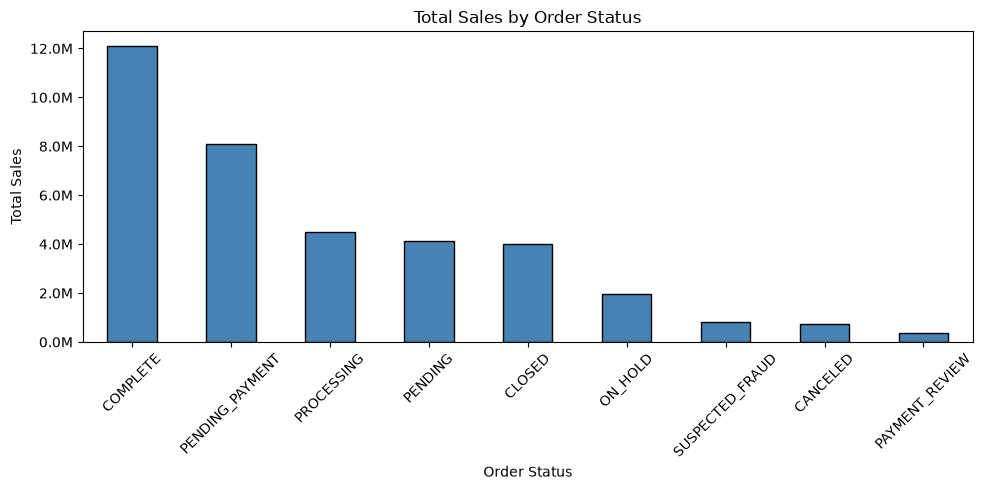

In [4]:
from matplotlib.ticker import FuncFormatter

ax = (
    df.groupby('Order_Status')['Sales']
      .sum()
      .sort_values(ascending=False)
      .plot(
          kind='bar',
          figsize=(10,5),
          color='steelblue',
          edgecolor='black'
      )
)

ax.set_title('Total Sales by Order Status')
ax.set_xlabel('Order Status')
ax.set_ylabel('Total Sales')

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# Insted of this, I wanna do an ANOVA test to see if there is a significant difference in the mean sales across different order statuses.
# But firstly I wanna know more about how to do it with scipy.

order_status_list = df['Order_Status'].unique().tolist()

for status in order_status_list:
    print(f"Order Status: {status}")
    print(df[df['Order_Status'] == status]['Benefit_per_order'].describe())
    print("\n")

Order Status: COMPLETE
count    59487.000000
mean        22.207861
std        103.756676
min      -4275.000000
25%          7.000000
50%         32.000000
75%         65.000000
max        912.000000
Name: Benefit_per_order, dtype: float64


Order Status: PENDING
count    20224.000000
mean        21.527690
std        103.131431
min      -2351.000000
25%          7.000000
50%         31.000000
75%         65.000000
max        720.000000
Name: Benefit_per_order, dtype: float64


Order Status: CLOSED
count    19616.000000
mean        23.343291
std        105.990046
min      -3366.000000
25%          8.000000
50%         32.000000
75%         66.000000
max        698.000000
Name: Benefit_per_order, dtype: float64


Order Status: PENDING_PAYMENT
count    39829.000000
mean        21.184991
std        104.719110
min      -3000.000000
25%          7.000000
50%         32.000000
75%         65.000000
max        720.000000
Name: Benefit_per_order, dtype: float64


Order Status: CANCELED
count    

In [6]:
# as we can see, the order includes more than one status so, let's filter the data to only include COMPLETE orders.
df_Com_Stat= df[df['Order_Status'] == 'COMPLETE']

### EDA_Function : 
Calculates and displays the main descriptive statistics of a numerical variable for exploratory data analysis (EDA).

In [7]:
# I know we can use df.describe() to get the summary statistics, but I want to create a function that will give me more information about the data.

def EDA (x):
    min_value = x.min()
    max_value = x.max()

    mode_value = x.mode()[0]
    mean_value = x.mean()

    first_quartile = x.quantile(0.25)
    median_value = x.median()
    third_quartile = x.quantile(0.75)

    var = x.var()
    std = x.std()

    skewness = x.skew()
    kurtosis = x.kurtosis()


    print("Minimum: ", min_value)
    print("Maximum: ", max_value)
    print("Mean: ", mean_value)
    print("Mode: ", mode_value)
    print("First Quartile: ", first_quartile)
    print("Median: ", median_value)
    print("Third Quartile: ", third_quartile)
    print("Variance: ", var)
    print("Standard Deviation: ", std)
    print("Skewness: ", skewness)
    print("Kurtosis: ", kurtosis)

In [8]:
EDA(df_Com_Stat['Days_for_shipment_(scheduled)'])

Minimum:  0
Maximum:  4
Mean:  2.926084690772774
Mode:  4
First Quartile:  2.0
Median:  4.0
Third Quartile:  4.0
Variance:  1.8893856434342178
Standard Deviation:  1.3745492510034762
Skewness:  -0.7199653743442119
Kurtosis:  -1.042698531368177


In [9]:
EDA(df_Com_Stat['Sales_per_customer'])

Minimum:  7.0
Maximum:  1940.0
Mean:  182.51078386874443
Mode:  123.0
First Quartile:  104.0
Median:  164.0
Third Quartile:  246.0
Variance:  14776.520741555123
Standard Deviation:  121.55871314535673
Skewness:  3.081439011217714
Kurtosis:  26.168083772515715


In [10]:
EDA(df_Com_Stat['Sales'])

Minimum:  10.0
Maximum:  2000.0
Mean:  203.32623934641182
Mode:  200.0
First Quartile:  120.0
Median:  200.0
Third Quartile:  300.0
Variance:  18012.993236610368
Standard Deviation:  134.21249284850634
Skewness:  3.09150494958978
Kurtosis:  26.396449953019797


In [11]:
EDA(df_Com_Stat['Benefit_per_order'])

Minimum:  -4275.0
Maximum:  912.0
Mean:  22.207860540958528
Mode:  15.0
First Quartile:  7.0
Median:  32.0
Third Quartile:  65.0
Variance:  10765.447883609775
Standard Deviation:  103.75667633270534
Skewness:  -4.844694513836677
Kurtosis:  85.7256463211181


In [12]:
EDA(df_Com_Stat['Order_Profit_Per_Order']) #‼️‼️ we should delete this column because it is the same as Benefit_per_order

Minimum:  -4275.0
Maximum:  912.0
Mean:  22.207860540958528
Mode:  15.0
First Quartile:  7.0
Median:  32.0
Third Quartile:  65.0
Variance:  10765.447883609775
Standard Deviation:  103.75667633270534
Skewness:  -4.844694513836677
Kurtosis:  85.7256463211181


In [13]:
df_Com_Stat.drop('Order_Profit_Per_Order', axis=1, inplace=True)

In [14]:
EDA(df_Com_Stat['Order_Item_Discount'])

Minimum:  0.0
Maximum:  500.0
Mean:  20.763276009884514
Mode:  0.0
First Quartile:  5.0
Median:  14.0
Third Quartile:  30.0
Variance:  487.05064137395675
Standard Deviation:  22.069223850737405
Skewness:  3.0974771724748185
Kurtosis:  26.070991933271422


In [15]:
EDA(df_Com_Stat['Order_Item_Profit_Ratio'])

Minimum:  -3.0
Maximum:  0.0
Mean:  -0.12364045926000639
Mode:  0.0
First Quartile:  0.0
Median:  0.0
Third Quartile:  0.0
Variance:  0.1888112231809611
Standard Deviation:  0.4345241341754921
Skewness:  -3.885973741628967
Kurtosis:  15.68169547110154


In [16]:
# as we noticed, there are may some columns with same values, regarding they have diff columns names.
# so used my ai assistant to check every column 
# then delete it

duplicate_cols = []

for i in range(len(df_Com_Stat.columns)):
    for j in range(i + 1, len(df_Com_Stat.columns)):
        if df_Com_Stat.iloc[:, i].equals(df_Com_Stat.iloc[:, j]):
            print(f"{df_Com_Stat.columns[i]}  <-->  {df_Com_Stat.columns[j]}")
            duplicate_cols.append(df_Com_Stat.columns[j])  # Keep the first, mark the second

df_Com_Stat = df_Com_Stat.drop(columns=duplicate_cols)

print("Dropped columns:", duplicate_cols)

Sales_per_customer  <-->  Order_Item_Total
Category_Id  <-->  Product_Category_Id
Customer_Email  <-->  Customer_Password


Customer_Id  <-->  Order_Customer_Id
Order_Item_Cardprod_Id  <-->  Product_Card_Id
Dropped columns: ['Order_Item_Total', 'Product_Category_Id', 'Customer_Password', 'Order_Customer_Id', 'Product_Card_Id']


### EDA_Plots(descriptive 0nly):
Here, we will answer some basic business questions.

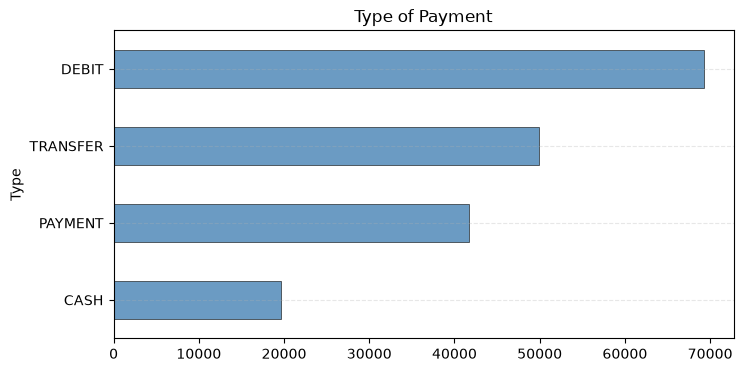

In [17]:
ax= df.groupby(['Type'])['Type'].count().sort_values(ascending=True).plot(kind='barh', title='Type of Payment', figsize=(8, 4), alpha=0.8, color='steelblue', edgecolor='black', linewidth=0.5)
ax.grid(axis='y', linestyle='--', alpha=0.3)

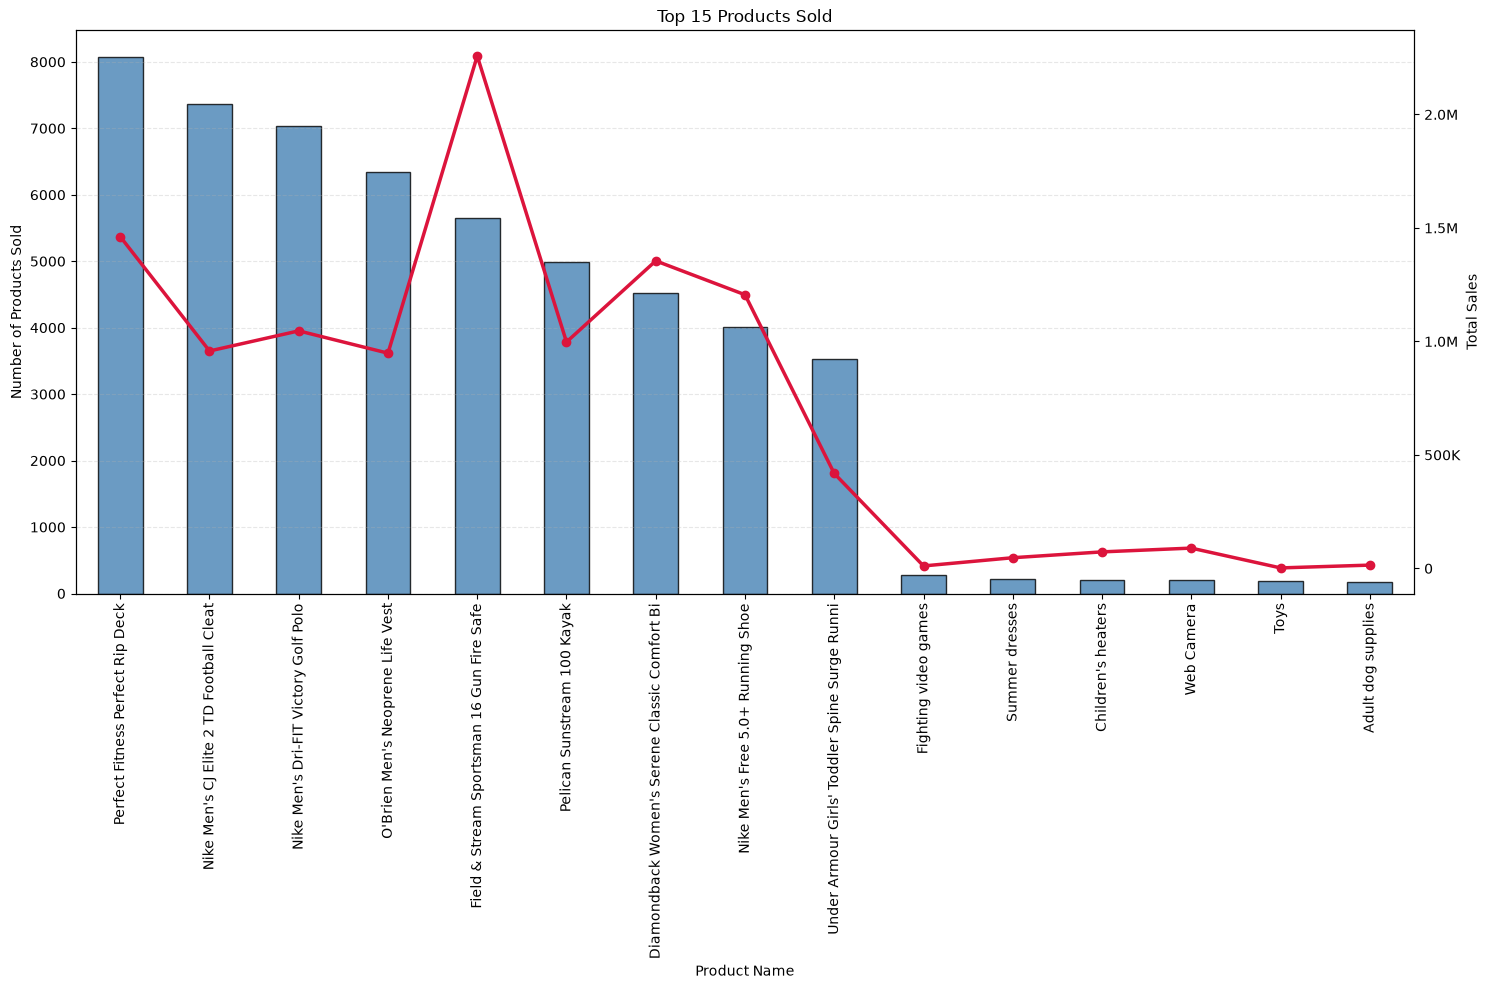

In [18]:
# Create summary table
top_products = (
    df_Com_Stat
    .groupby('Product_Name')
    .agg(
        Products_Sold=('Product_Name', 'count'),
        Total_Sales=('Sales', 'sum')
    )
    .sort_values('Products_Sold', ascending=False)
    .head(15)
)

# Create figure
fig, ax1 = plt.subplots(figsize=(15,10))

# Bar chart
top_products['Products_Sold'].plot(
    kind='bar',
    ax=ax1,
    color='steelblue',
    edgecolor='black',
    alpha=0.8
)

ax1.set_title('Top 15 Products Sold')
ax1.set_xlabel('Product Name')
ax1.set_ylabel('Number of Products Sold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Second axis for sales
ax2 = ax1.twinx()

# Line chart
ax2.plot(
    top_products.index,
    top_products['Total_Sales'],
    color='crimson',
    marker='o',
    linewidth=2.5
)

def human_format(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.0f}K'
    else:
        return f'{x:.0f}'

ax2.yaxis.set_major_formatter(FuncFormatter(human_format))

ax2.set_ylabel('Total Sales')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

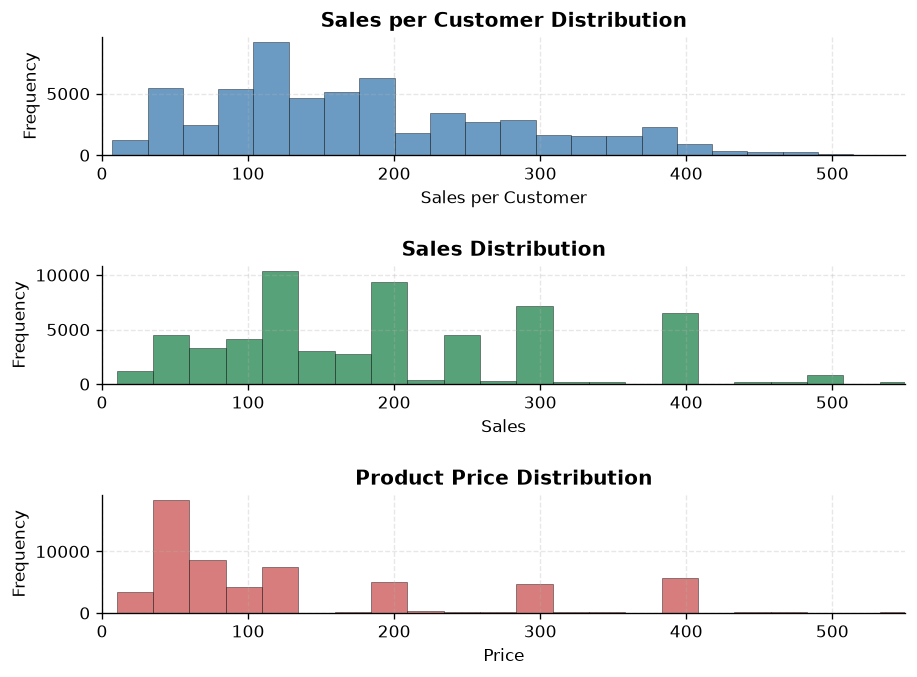

In [19]:
fig, ax = plt.subplots(3, 1, figsize=(8, 6), dpi=120)

ax[0].hist(df_Com_Stat['Sales_per_customer'], bins=80, alpha=0.8,
           color='steelblue', edgecolor='black', linewidth=0.3)
ax[0].set_title('Sales per Customer Distribution', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Sales per Customer')
ax[0].set_ylabel('Frequency')
ax[0].set_xlim(0, 550)
ax[0].grid(alpha=0.3, linestyle='--')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[2].hist(df_Com_Stat['Product_Price'], bins=80, alpha=0.8,
           color='indianred', edgecolor='black', linewidth=0.3)
ax[2].set_title('Product Price Distribution', fontsize=12, fontweight='bold')
ax[2].set_xlabel('Price')
ax[2].set_ylabel('Frequency')
ax[2].set_xlim(0, 550)
ax[2].grid(alpha=0.3, linestyle='--')
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)

ax[1].hist(df_Com_Stat['Sales'], bins=80, alpha=0.8,
           color='seagreen', edgecolor='black', linewidth=0.3)
ax[1].set_title('Sales Distribution', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Sales')
ax[1].set_ylabel('Frequency')
ax[1].set_xlim(0, 550)
ax[1].grid(alpha=0.3, linestyle='--')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

In [20]:
df_Com_Stat = df_Com_Stat.sort_values(by='shipping_date_(DateOrders)')
df_Com_Stat['Month'] = df_Com_Stat['shipping_date_(DateOrders)'].dt.month
df_Com_Stat['Year'] = df_Com_Stat['shipping_date_(DateOrders)'].dt.year


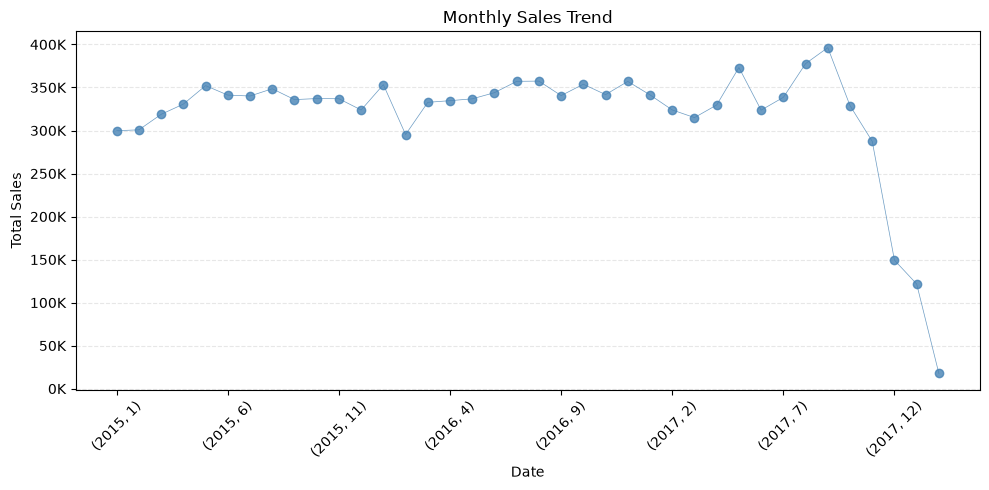

In [21]:
from matplotlib.ticker import FuncFormatter


ax = (
    df_Com_Stat.groupby(['Year', 'Month'])['Sales']
      .sum()
      .plot(
          kind='line',
          marker='o',
          figsize=(10, 5),
          title='Monthly Sales Trend',
          xlabel='Date',
          ylabel='Total Sales', alpha=0.8, color='steelblue', linewidth=0.5
      )
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
df = df.sort_values(by='shipping_date_(DateOrders)')
df['Month'] = df['shipping_date_(DateOrders)'].dt.month
df['Year'] = df['shipping_date_(DateOrders)'].dt.year


pivot = df.pivot_table(
    values='Sales',
    index='Order_Region',
    columns='Year',
    aggfunc='sum'
    )

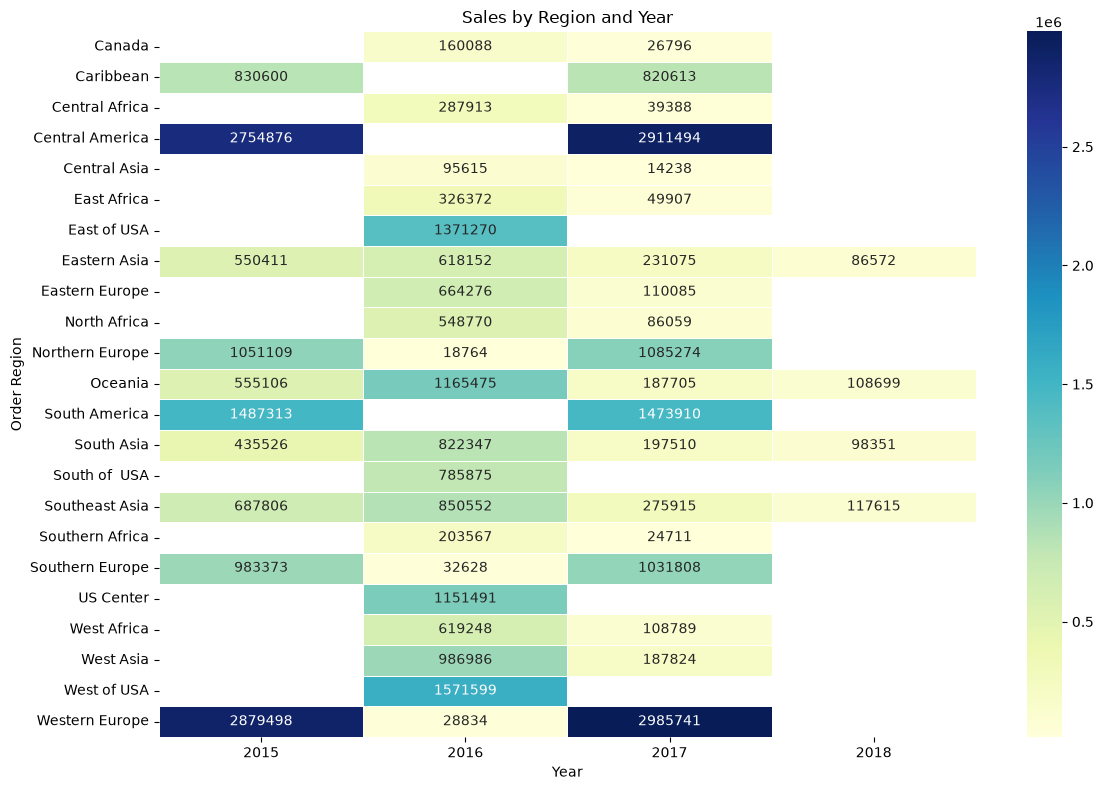

In [23]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Sales by Region and Year')
plt.xlabel('Year')
plt.ylabel('Order Region')
plt.tight_layout()
plt.show()

<Axes: >

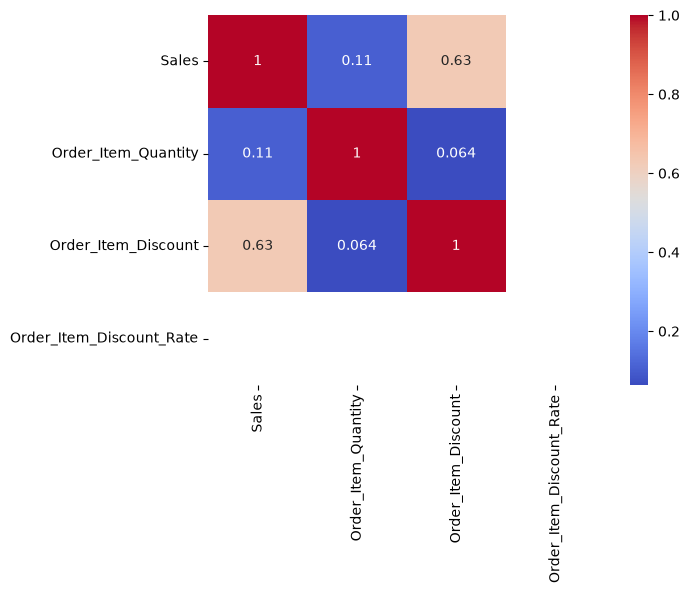

In [24]:
df_h = df_Com_Stat[['Sales', 'Order_Item_Quantity', 'Order_Item_Discount', 'Order_Item_Discount_Rate']].corr()
sns.heatmap(df_h, annot=True, cmap='coolwarm')

In [25]:
(df_Com_Stat
 .groupby('Order_Item_Discount_Rate')['Sales']
 .sum()
 .reset_index())

,Order_Item_Discount_Rate,Sales
0,0.0,12095268.0


<Axes: xlabel='Sales', ylabel='Order_Item_Discount_Rate'>

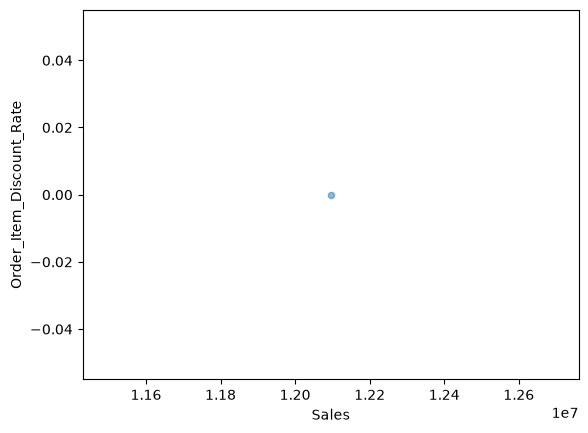

In [26]:
(df_Com_Stat
 .groupby('Order_Item_Discount_Rate')['Sales']
 .sum()
 .reset_index()
 .plot.scatter(
     x='Sales',
     y='Order_Item_Discount_Rate',
     alpha=0.5
 ))

In [27]:
# for ex and i wanna do anova:
"""
from scipy.stats import ttest_ind

late = df[df["Late_delivery_risk"]==1]["Sales"]
ontime = df[df["Late_delivery_risk"]==0]["Sales"]

t,p = ttest_ind(late, ontime)

print(t,p)
"""

'\nfrom scipy.stats import ttest_ind\n\nlate = df[df["Late_delivery_risk"]==1]["Sales"]\nontime = df[df["Late_delivery_risk"]==0]["Sales"]\n\nt,p = ttest_ind(late, ontime)\n\nprint(t,p)\n'